## Challenge

In [82]:
import sys
import os
import numpy as np
import pandas as pd
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from dotenv import load_dotenv
project_root = '/home/onyxia/work/electera'
sys.path.insert(0, project_root)
from src.components.data_processing.data_loader import DataLoader
load_dotenv()

False

In [83]:
import os
import s3fs
os.environ["AWS_ACCESS_KEY_ID"] = 'XXXA4621E5RGRXZTKPF2'
os.environ["AWS_SECRET_ACCESS_KEY"] = '89rKPtUp0zK9KgK7KYiP0gMFSGewb3aCIL7p98Tt'
os.environ["AWS_SESSION_TOKEN"] = 'eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiJYWFhBNDYyMUU1UkdSWFpUS1BGMiIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzczNDAwMjgzLCJhenAiOiJvbnl4aWEiLCJjbmYiOnsiamt0IjoidEJITk9sZEdBYXFEdVJpZEgtVFUyT1lqa0RUN3o2LVdKclpES3gwVHA5USJ9LCJlbWFpbCI6ImFydGh1ci5tYW5jZWF1QHN0dWRlbnQtY3MuZnIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZXhwIjoxNzc1MjA3NjE5LCJmYW1pbHlfbmFtZSI6Ik1hbmNlYXUiLCJnaXZlbl9uYW1lIjoiQXJ0aHVyIiwiZ3JvdXBzIjpbIlVTRVJfT05ZWElBIl0sImlhdCI6MTc3NDYwMjgxOSwiaXNzIjoiaHR0cHM6Ly9hdXRoLmxhYi5zc3BjbG91ZC5mci9hdXRoL3JlYWxtcy9zc3BjbG91ZCIsImp0aSI6Im9ucnRydDpjOTNjNzJhYS1kZGYyLWViZmQtZWNhNi00Y2M4ZDIzMjM1NDYiLCJsb2NhbGUiOiJlbiIsIm5hbWUiOiJBcnRodXIgTWFuY2VhdSIsInBvbGljeSI6InN0c29ubHkiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJhcnRodXJtYW5jZWF1IiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiJkYjViMDU0NC02NjA4LTU5NGItOGE0ZC1hMjkzMDZhNDRlZGEiLCJzdWIiOiJiYzc3Yjk3YS1lN2VkLTQ4ZWMtYmQ4Zi1lNzBjYjZhMTYyZGIiLCJ0eXAiOiJEUG9QIn0.TKYuZ6s1hiI0MH3GCWK5D4ZPndF_D4arI0UjNvJHVO4zLB2v_7XrCuq7Sx0O_pcPmPq4FjZX_Wdf8EOR8clgfQ'
os.environ["AWS_DEFAULT_REGION"] = 'us-east-1'
fs = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])

Ingestion+traitement PLM

In [130]:
election_2026_t2 = DataLoader().load_dataset('s3://arthurmanceau/election_modeling_uhcp/data/raw/elections/municipales/2026/muni2026_csv/muni2026comm_t2.parquet')
election_2026 = DataLoader().load_dataset('s3://arthurmanceau/election_modeling_uhcp/data/raw/elections/municipales/2026/muni2026_csv/muni2026comm.parquet')
election_2014 = DataLoader().load_dataset('s3://arthurmanceau/election_modeling_uhcp/data/raw/elections/municipales/2014/muni2014_csv/muni2014comm.parquet')

2026-03-27 11:24:59.444 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:62 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/raw/elections/municipales/2026/muni2026_csv/muni2026comm_t2.parquet...


2026-03-27 11:24:59.924 | DEBUG    | src.components.data_processing.data_loader:load_dataset:205 - Dataset loaded: (1526, 73)
2026-03-27 11:24:59.956 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:62 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/raw/elections/municipales/2026/muni2026_csv/muni2026comm.parquet...
2026-03-27 11:25:00.265 | DEBUG    | src.components.data_processing.data_loader:load_dataset:205 - Dataset loaded: (34830, 75)
2026-03-27 11:25:00.303 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:62 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/raw/elections/municipales/2014/muni2014_csv/muni2014comm.parquet...
2026-03-27 11:25:00.610 | DEBUG    | src.components.data_processing.data_loader:load_dataset:205 - Dataset loaded: (36350, 63)


In [131]:
election_2026_t2['dep_num'] =  election_2026_t2['dep'].replace({'A':20.0, 'B':20.0}, regex=True).astype(float)
election_2026['dep_num'] =  election_2026['dep'].replace({'A':20.0, 'B':20.0}, regex=True).astype(float)
election_2014['dep_num'] =  election_2014['dep'].replace({'A':20.0, 'B':20.0}, regex=True).astype(float)

print(len(election_2026_t2))
election_2026_t2 = election_2026_t2[(election_2026_t2['dep_num']<= 95.0) & (election_2026_t2['dep_num']>=1.0)]
print(len(election_2026_t2))

print(len(election_2026))
election_2026 = election_2026[(election_2026['dep_num']<= 95.0) & (election_2026['dep_num']>=1.0)]
print(len(election_2026))

print(len(election_2014))
election_2014 = election_2014[(election_2014['dep_num']<= 95.0) & (election_2014['dep_num']>=1.0)]
print(len(election_2014))

1526
1445
34830
34666
36350
36350


In [132]:
election_2026_t2['year'] = 2026
election_2026_t2['tour'] = 2
election_2026_t2['type'] = "muni"
election_2026_t2['dep_num'] = election_2026_t2['dep']

election_2026['year'] = 2026
election_2026['tour'] = 1
election_2026['type'] = "muni"

election_2014['year'] = 2014
election_2014['tour'] = 1
election_2014['type'] = "muni"

elections = pd.concat([pd.concat([election_2014, election_2026]), election_2026_t2], axis=0)

In [86]:
socio_eco = DataLoader().load_dataset('s3://arthurmanceau/election_modeling_uhcp/data/derived/cache/dfc_cached.parquet')

2026-03-27 11:14:10.290 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:62 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/derived/cache/dfc_cached.parquet...


2026-03-27 11:14:43.642 | DEBUG    | src.components.data_processing.data_loader:load_dataset:205 - Dataset loaded: (38145, 31557)


In [133]:
features = ['agesexcommunes/age2018',
 'agesexcommunes/pop2018',
 'cspcommunes/pact2018',
 'cspcommunes/pagri2018',
 'cspcommunes/pindp2018',
 'cspcommunes/pcadr2018',
 'cspcommunes/ppint2018',
 'cspcommunes/pempl2018',
 'cspcommunes/pouvr2018',
 'cspcommunes/paind2018',
 'cspcommunes/paica2018',
 'cspcommunes/pouem2018',
 'cspcommunes/pcapi2018',
 'cspcommunes/pchom2018',
 'basesfiscalescommunes/tauxfoncier2018',
 'capitalimmobiliercommunes/prixm2ratio2018',
 'diplomesdepartements/psup2018',
 'proprietairescommunes/ppropri2018',
 'popcommunesvbbm/vbbm2018',
'pibdepartements/pibhab2018',
'etrangerscommunes/petranger2018',
'revcommunes/revratio2018', 'codecommune']

In [134]:
socio_eco_filtered = socio_eco[features]

In [135]:
data = elections.merge(socio_eco_filtered, on='codecommune', how='left')

In [ ]:
data.loc[:, ['tour', 'year', 'nb_list', 'pabs']+features]#.dropna()

,tour,year,nb_list,pabs,agesexcommunes/age2018,agesexcommunes/pop2018,cspcommunes/pact2018,cspcommunes/pagri2018,cspcommunes/pindp2018,cspcommunes/pcadr2018,...,cspcommunes/pchom2018,basesfiscalescommunes/tauxfoncier2018,capitalimmobiliercommunes/prixm2ratio2018,diplomesdepartements/psup2018,proprietairescommunes/ppropri2018,popcommunesvbbm/vbbm2018,pibdepartements/pibhab2018,etrangerscommunes/petranger2018,revcommunes/revratio2018,codecommune
0,1,2014,4,0.4073,42.126530,759.0,306.0,0.003268,0.084967,0.143791,...,0.084967,0.141213,0.719930,0.294438,0.822165,1.0,0.731279,0.008997,1.096172,01001
1,1,2014,1,0.1637,37.946354,270.0,94.0,0.000000,0.276596,0.138298,...,0.074468,0.123875,0.472579,0.294438,0.810345,1.0,0.731279,0.008000,1.047167,01002
2,1,2014,3,0.3551,44.395008,105.0,61.0,0.000000,0.000000,0.000000,...,0.000000,0.154701,0.582246,0.294438,0.661972,1.0,0.731279,0.062500,1.018453,01006
3,1,2014,2,0.3930,38.119133,773.0,320.0,0.000000,0.050000,0.112500,...,0.028125,0.163896,0.684019,0.294438,0.718182,2.0,0.731279,0.023841,1.068166,01008
4,1,2014,1,0.3088,48.344734,321.0,134.0,0.000000,0.201493,0.007463,...,0.029851,0.066225,0.560522,0.294438,0.817647,1.0,0.731279,0.030395,1.408379,01009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72456,2,2026,4,0.4673,39.404018,18272.0,6358.0,0.000000,0.060396,0.248663,...,0.075495,0.143028,1.316012,0.336019,0.590133,3.0,0.865744,0.117615,1.204876,95598
72457,2,2026,3,0.4398,36.024151,4586.0,1675.0,0.000000,0.093134,0.142687,...,0.072239,0.183042,1.014789,0.336019,0.783660,3.0,0.865744,0.139636,0.846481,95612
72458,2,2026,2,0.2000,38.798473,614.0,192.0,0.036458,0.015625,0.213542,...,0.000000,0.109211,0.963784,0.336019,0.887931,1.0,0.865744,0.032841,1.625421,95627
72459,2,2026,3,0.4105,34.564983,2567.0,1022.0,0.004892,0.035225,0.206458,...,0.058708,0.195378,1.050061,0.336019,0.712029,2.0,0.865744,0.063847,1.190314,95641


/tmp/ipykernel_31407/2007026191.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_2026 = data.loc[(data['year']==2026) & (data['tour']==1)].groupby(pd.qcut(data.loc[(data['year']==2026) & (data['tour']==1)][col], q=20))['pabs'].mean()
/tmp/ipykernel_31407/2007026191.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_2026_t2 = data.loc[(data['year']==2026) & (data['tour']==2)].groupby(pd.qcut(data.loc[(data['year']==2026) & (data['tour']==2)][col], q=20))['pabs'].mean()
/tmp/ipykernel_31407/2007026191.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

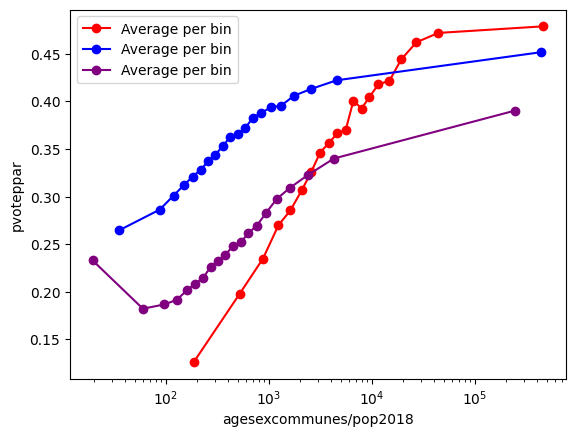

In [165]:
col = 'agesexcommunes/pop2018'

# Group by bins and calculate mean
grouped_2026 = data.loc[(data['year']==2026) & (data['tour']==1)].groupby(pd.qcut(data.loc[(data['year']==2026) & (data['tour']==1)][col], q=20))['pabs'].mean()
grouped_2026_t2 = data.loc[(data['year']==2026) & (data['tour']==2)].groupby(pd.qcut(data.loc[(data['year']==2026) & (data['tour']==2)][col], q=20))['pabs'].mean()
grouped_2014 = data.loc[(data['year']==2014) & (data['tour']==1)].groupby(pd.qcut(data.loc[(data['year']==2014) & (data['tour']==1)][col], q=20))['pabs'].mean()

# Plot average per bin
plt.plot([interval.mid for interval in grouped_2026_t2.index], grouped_2026_t2.values, color='red', marker='o', label='Average per bin')
plt.plot([interval.mid for interval in grouped_2026.index], grouped_2026.values, color='blue', marker='o', label='Average per bin')
plt.plot([interval.mid for interval in grouped_2014.index], grouped_2014.values, color='purple', marker='o', label='Average per bin')

plt.xlabel(col)
plt.ylabel('pvoteppar')
plt.legend()
plt.xscale('log')
plt.show()